In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Data

In [2]:
fracas_df = pd.read_csv("fracas.csv")
fracas_df_filtered = fracas_df[(fracas_df['multiple_p']==0) & fracas_df['fracas_answer'].isin(['yes', 'no'])]
fracas_df_filtered.head()

,section,subsection,problem_id,fracas_answer,fracas_nonstandard,multiple_p,p,h,a,include,comment,inference_possible,minimal_layers
0,1 GENERALIZED QUANTIFIERS,1.1 Conservativity,1,yes,NaN,0,An Italian became the world's greatest tenor.,There was an Italian who became the world's gr...,Yes,0,degree,1,"temp, quant, num, def, degree"
4,1 GENERALIZED QUANTIFIERS,1.1 Conservativity,5,yes,NaN,0,The really ambitious tenors are Italian.,There are really ambitious tenors who are Ital...,Yes,done,NaN,1,"temp, quant, num, def"
5,1 GENERALIZED QUANTIFIERS,1.1 Conservativity,6,no,NaN,0,No really great tenors are modest.,There are really great tenors who are modest.,No,done,NaN,1,"temp, quant, num, def, neg"
6,1 GENERALIZED QUANTIFIERS,1.1 Conservativity,7,yes,NaN,0,Some great tenors are Swedish.,There are great tenors who are Swedish.,Yes,done,NaN,1,"temp, quant, num, def"
7,1 GENERALIZED QUANTIFIERS,1.1 Conservativity,8,yes,NaN,0,Many great tenors are German.,There are great tenors who are German.,Yes,done,many?,1,"temp, quant, num, def"


# Check Minimal Layer Counts for FraCaS subset

In [3]:
fracas_df['minimal_layers'].value_counts()

minimal_layers
temp, quant, num, def                                46
temp, quant, num, def, degree                        12
temp, quant, num, def, loc                           11
temp, quant, num, def, duration                       8
temp, quant, num, def, PARALLEL                       5
temp, quant, num, def, mod                            4
temp, quant, num, def, manner, PARALLEL               4
temp, quant, num, def, duration, aspect               4
temp, quant, num, def, neg                            3
temp, quant, num, def, mod, PARALLEL                  3
temp, quant, num, def, modal, manner, CONSEQUENCE     3
temp, quant, num, def, duration, loc                  3
temp, quant, num, def, distributivity                 3
temp, quant, num, def, neg, manner                    2
temp, quant, num, def, manner, BEFORE                 2
temp, quant, num, def, neg, loc                       1
temp, quant, num, def, manner                         1
temp, quant, num, def, neg, CONSE

In [4]:
fracas_df['minimal_layers'].str.split(',').explode().value_counts()

minimal_layers
temp               123
 quant             123
 num               123
 def               123
 duration           16
 loc                15
 manner             14
 degree             12
 PARALLEL           12
 neg                 7
 mod                 7
 modal               6
 BEFORE              4
 aspect              4
 CONSEQUENCE         3
 distributivity      3
 RESULT              2
 CONSEQUENCE         1
 question            1
 frequency           1
Name: count, dtype: int64

# Check Problem Distribution

In [3]:
import re

def plot_remaining_distribution(summary_section):
    # Extract leading number for sorting
    def extract_number(s):
        match = re.match(r"(\d+)", str(s))
        return int(match.group(1)) if match else float("inf")

    summary_section = summary_section.copy()
    summary_section["order"] = summary_section.index.map(extract_number)

    # Sort by original numeric order
    summary_section = summary_section.sort_values("order")

    ax = summary_section["percentage"].plot(kind="barh", figsize=(8, 5))

    plt.title("Remaining Problems per Section after Filtering (%)")
    plt.xlabel("Percentage (%)")
    plt.ylabel("Section")

    # Add count labels
    for i, (idx, row) in enumerate(summary_section.iterrows()):
        ax.text(
            row["percentage"] + 1,
            i,
            f'{int(row["remaining"])}/{int(row["total"])}',
            va="center",
            fontsize=9
        )

    plt.tight_layout()
    plt.show()

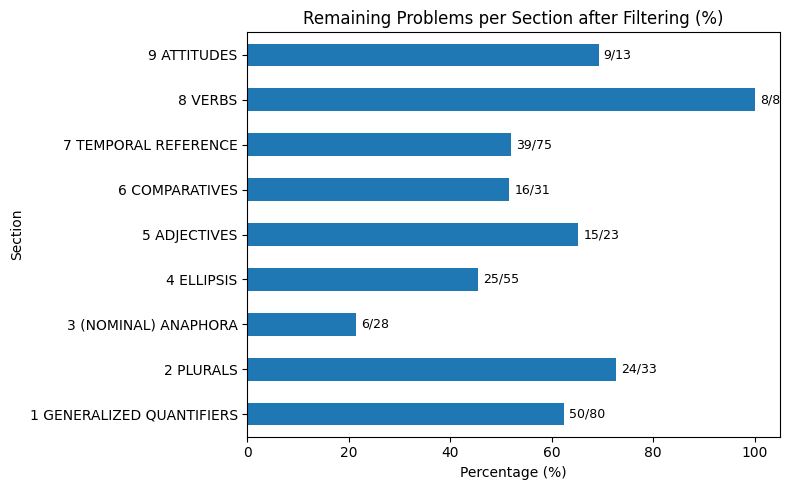

In [6]:
filtered_one_premise = fracas_df[(fracas_df["multiple_p"] == 0)]

total_section = fracas_df.groupby("section").size()
remaining_section = filtered_one_premise.groupby("section").size()

summary_section = (
    pd.concat([total_section, remaining_section], axis=1)
    .fillna(0)
    .rename(columns={0: "total", 1: "remaining"})
)

summary_section["percentage"] = (
    summary_section["remaining"] / summary_section["total"] * 100
)

plot_remaining_distribution(summary_section)

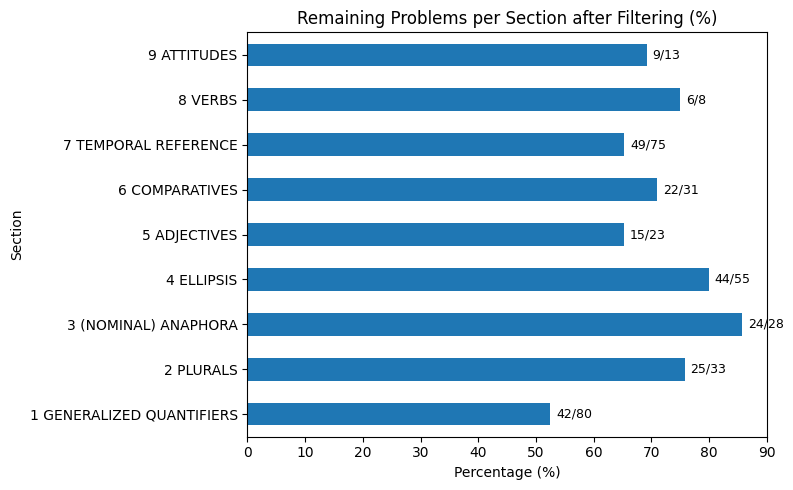

In [7]:
filtered_one_premise = fracas_df[(fracas_df["fracas_answer"].isin(['yes', 'no']))]

total_section = fracas_df.groupby("section").size()
remaining_section = filtered_one_premise.groupby("section").size()

summary_section = (
    pd.concat([total_section, remaining_section], axis=1)
    .fillna(0)
    .rename(columns={0: "total", 1: "remaining"})
)

summary_section["percentage"] = (
    summary_section["remaining"] / summary_section["total"] * 100
)

plot_remaining_distribution(summary_section)

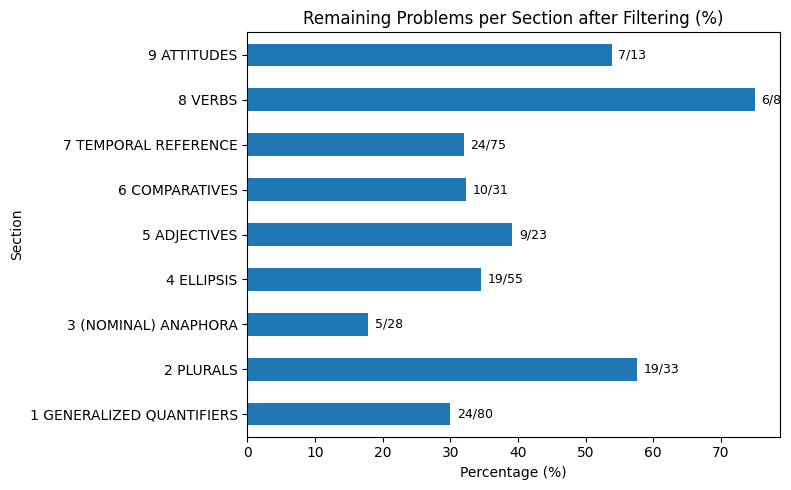

In [8]:
filtered_one_premise_yes_no = fracas_df[(fracas_df["multiple_p"] == 0) & (fracas_df["fracas_answer"].isin(['yes', 'no']))]

total_section = fracas_df.groupby("section").size()
remaining_section = filtered_one_premise_yes_no.groupby("section").size()

summary_section = (
    pd.concat([total_section, remaining_section], axis=1)
    .fillna(0)
    .rename(columns={0: "total", 1: "remaining"})
)

summary_section["percentage"] = (
    summary_section["remaining"] / summary_section["total"] * 100
)

plot_remaining_distribution(summary_section)

In [9]:
def prepare_inference_distribution(filtered_df):
    dist = (
        filtered_df
        .groupby(["section", "inference_possible"], sort=False)
        .size()
        .unstack(fill_value=0)
    )

    for col in ["1", "0", "?"]:
        if col not in dist.columns:
            dist[col] = 0

    dist = dist[["1", "0", "?"]] 

    def extract_number(s):
        match = re.match(r"(\d+)", str(s))
        return int(match.group(1)) if match else float("inf")

    dist["order"] = dist.index.map(extract_number)
    dist = dist.sort_values("order").drop(columns="order")

    return dist


def plot_inference_distribution(filtered_df):
    dist = prepare_inference_distribution(filtered_df)

    ax = dist.plot(
        kind="barh",
        stacked=True,
        figsize=(10, 6)
    )

    plt.title("Solvable Problems per Section")
    plt.xlabel("Count")
    plt.ylabel("Section")

    for i, (section, row) in enumerate(dist.iterrows()):
        cumulative = 0
        for val in dist.columns:
            count = row[val]
            if count > 0:
                ax.text(
                    cumulative + count / 2,
                    i,
                    str(int(count)),
                    ha="center",
                    va="center",
                    fontsize=9
                )
            cumulative += count

    plt.legend(title="Inference Possible")
    plt.tight_layout()
    plt.show()

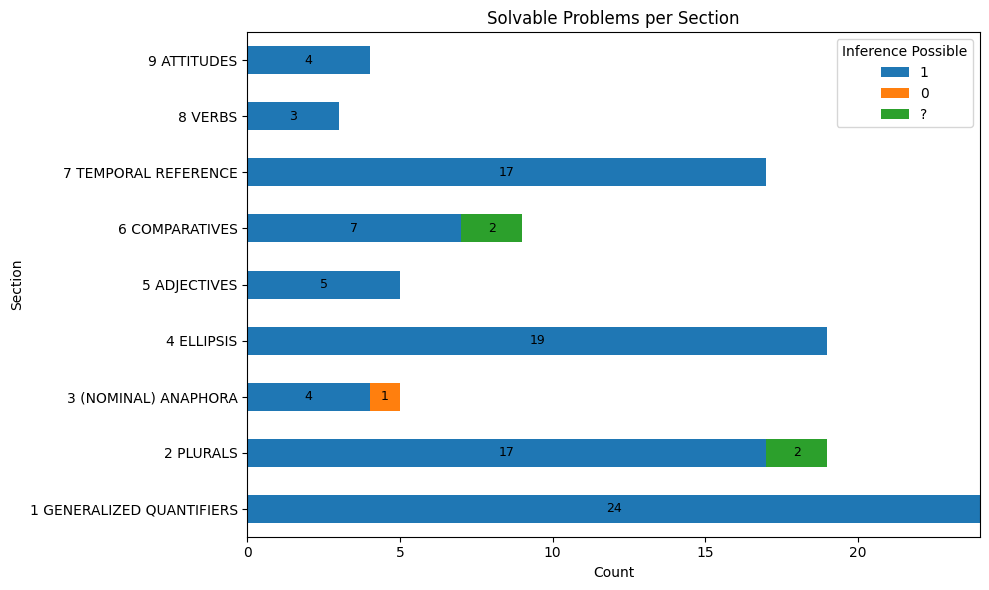

In [10]:
plot_inference_distribution(filtered_one_premise_yes_no)